In [2]:
from google.colab import files
uploaded = files.upload()
print(uploaded)

Saving Country-data.csv to Country-data.csv
{'Country-data.csv': b'country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp\r\nAfghanistan,90.2,10,7.58,44.9,1610,9.44,56.2,5.82,553\r\nAlbania,16.6,28,6.55,48.6,9930,4.49,76.3,1.65,4090\r\nAlgeria,27.3,38.4,4.17,31.4,12900,16.1,76.5,2.89,4460\r\nAngola,119,62.3,2.85,42.9,5900,22.4,60.1,6.16,3530\r\nAntigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200\r\nArgentina,14.5,18.9,8.1,16,18700,20.9,75.8,2.37,10300\r\nArmenia,18.1,20.8,4.4,45.3,6700,7.77,73.3,1.69,3220\r\nAustralia,4.8,19.8,8.73,20.9,41400,1.16,82,1.93,51900\r\nAustria,4.3,51.3,11,47.8,43200,0.873,80.5,1.44,46900\r\nAzerbaijan,39.2,54.3,5.88,20.7,16000,13.8,69.1,1.92,5840\r\nBahamas,13.8,35,7.89,43.7,22900,-0.393,73.8,1.86,28000\r\nBahrain,8.6,69.5,4.97,50.9,41100,7.44,76,2.16,20700\r\nBangladesh,49.4,16,3.52,21.8,2440,7.14,70.4,2.33,758\r\nBarbados,14.2,39.5,7.97,48.7,15300,0.321,76.7,1.78,16000\r\nBelarus,5.5,51.4,5.61,64.5,16200,15.1,7

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

In [4]:
df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [7]:
countries = df["country"]

X = df.drop("country", axis=1)

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]])

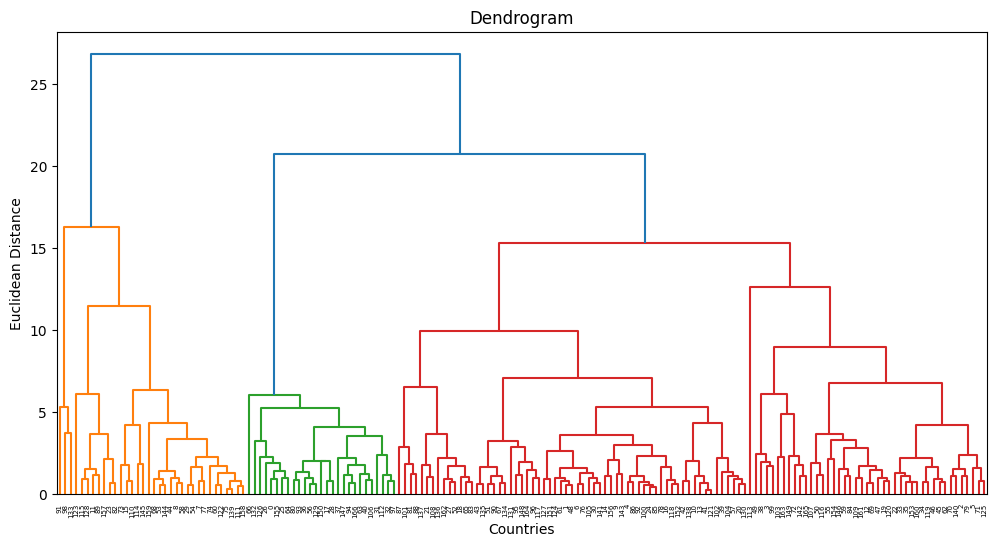

In [9]:
plt.figure(figsize=(12,6))

dendrogram(
    linkage(X_scaled, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Countries")
plt.ylabel("Euclidean Distance")

plt.show()

In [10]:
hc = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

clusters = hc.fit_predict(X_scaled)

In [11]:
df["Cluster"] = clusters

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1


In [12]:
df["Cluster"].value_counts()

,count
Cluster,
1,106
0,34
2,27


In [13]:
for i in range(3):

    print("\n")
    print("="*50)
    print("Cluster", i)
    print("="*50)

    print(df[df["Cluster"] == i]["country"])



Cluster 0
7                 Australia
8                   Austria
11                  Bahrain
15                  Belgium
23                   Brunei
29                   Canada
44                  Denmark
53                  Finland
54                   France
58                  Germany
60                   Greece
68                  Iceland
73                  Ireland
74                   Israel
75                    Italy
77                    Japan
82                   Kuwait
89                    Libya
91               Luxembourg
98                    Malta
110             Netherlands
111             New Zealand
114                  Norway
115                    Oman
122                Portugal
123                   Qatar
128            Saudi Arabia
133               Singapore
139                   Spain
144                  Sweden
145             Switzerland
157    United Arab Emirates
158          United Kingdom
159           United States
Name: country, dtype: object


Clust

In [14]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.961765,58.508824,8.501176,48.902941,47588.235294,4.115500,79.982353,1.888529,43170.588235
1,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925
2,105.070370,23.589630,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889


In [15]:
from sklearn.decomposition import PCA

In [16]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

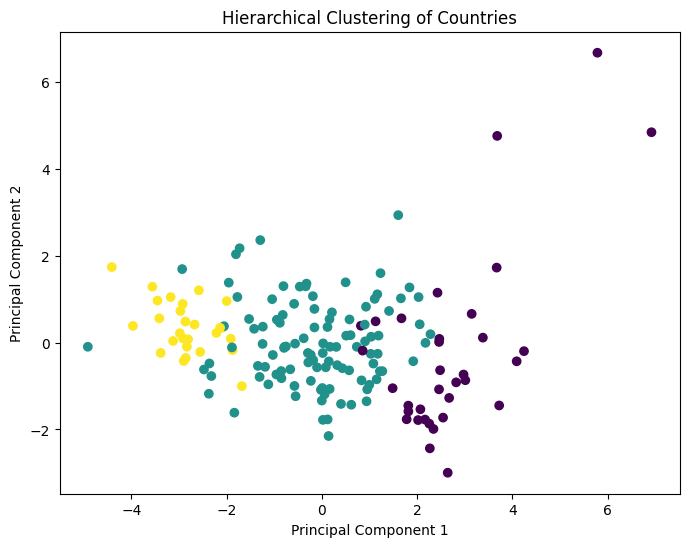

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title("Hierarchical Clustering of Countries")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [18]:
for cluster in sorted(df["Cluster"].unique()):

    print("\n")
    print(f"Cluster {cluster}")

    print(df[df["Cluster"] == cluster]["country"].head(10).tolist())



Cluster 0
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Denmark', 'Finland', 'France', 'Germany']


Cluster 1
['Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados']


Cluster 2
['Afghanistan', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', "Cote d'Ivoire"]


In [19]:
df["Cluster"].value_counts()

,count
Cluster,
1,106
0,34
2,27


In [20]:
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.961765,58.508824,8.501176,48.902941,47588.235294,4.115500,79.982353,1.888529,43170.588235
1,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925
2,105.070370,23.589630,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889
